# INST664 Final Project Notebook

## Language Patterns in Pet Adoption Profiles

This notebook analyzes the PetFinder adoption prediction dataset to examine whether the language used in pet adoption descriptions is related to adoption outcomes. The analysis begins with basic data cleaning and exploratory data analysis, then moves into description-length analysis, sentiment analysis, and text classification using TF-IDF features.

The main research question is:

**Do linguistic features in pet adoption profiles relate to adoption speed, and can adoption outcomes be predicted from profile descriptions?**

## 1. Load Data

The training data includes the target variable `AdoptionSpeed`, while the test data does not include the final adoption outcome.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

folder_path = '/content/drive/MyDrive/petfinder-adoption-prediction'
train_path = os.path.join(folder_path, 'train', 'train.csv')
test_path = os.path.join(folder_path, 'test', 'test.csv')

# Load the training dataset.
if os.path.exists(train_path):
    train_df = pd.read_csv(train_path)
    print('Loaded train_df successfully.')
    display(train_df.head())
else:
    print(f'Error: train.csv not found at {train_path}')

# Load the test dataset.
if os.path.exists(test_path):
    test_df = pd.read_csv(test_path)
    print('Loaded test_df successfully.')
    display(test_df.head())
else:
    print(f'Error: test.csv not found at {test_path}')

Loaded train_df successfully.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


Loaded test_df successfully.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt
0,2,Dopey & Grey,8,266,266,1,2,6,7,1,...,2,1,2,0,41326,2ece3b2573dcdcebd774e635dca15fd9,0,"Dopey Age: 8mths old Male One half of a pair, ...",e2dfc2935,2.0
1,2,Chi Chi,36,285,264,2,1,4,7,2,...,1,2,1,0,41326,2ece3b2573dcdcebd774e635dca15fd9,0,"Please note that Chichi has been neutered, the...",f153b465f,1.0
2,2,Sticky,2,265,0,1,6,7,0,2,...,2,1,1,200,41326,e59c106e9912fa30c898976278c2e834,0,"Sticky, named such because of his tendency to ...",3c90f3f54,4.0
3,1,Dannie & Kass [In Penang],12,307,0,2,2,5,0,2,...,1,1,2,0,41326,e59c106e9912fa30c898976278c2e834,0,Dannie and Kass are mother and daughter. We en...,e02abc8a3,5.0
4,2,Cuddles,12,265,0,1,2,3,7,2,...,1,1,1,0,41326,e59c106e9912fa30c898976278c2e834,0,"Extremely cuddly cat, hence the origin of his ...",09f0df7d1,5.0


## 2. Inspect the Dataset

This section checks the number of rows and columns, column names, and key variables used in the project.

Important variables for this project include:

- `Description`: the text profile written for each pet.
- `Type`: whether the pet is a dog or cat.
- `AdoptionSpeed`: the adoption outcome category.
- `Age`, `PhotoAmt`, and `Fee`: non-text features that may also influence adoption.

In [ ]:
print('Training data shape:', train_df.shape)
print('Test data shape:', test_df.shape)

Training data shape: (14993, 24)
Test data shape: (3972, 23)


In [ ]:
train_df.columns

Index(['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2',
       'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
       'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID',
       'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed'],
      dtype='object')

In [ ]:
train_df[['Description', 'Type', 'AdoptionSpeed', 'Age', 'Breed1', 'Gender']].head()

,Description,Type,AdoptionSpeed,Age,Breed1,Gender
0,Nibble is a 3+ month old ball of cuteness. He ...,2,2,3,299,1
1,I just found it alone yesterday near my apartm...,2,0,1,265,1
2,Their pregnant mother was dumped by her irresp...,1,3,1,307,1
3,"Good guard dog, very alert, active, obedience ...",1,2,4,307,2
4,This handsome yet cute boy is up for adoption....,1,2,1,307,1


In [ ]:
# Check missing values in variables that are important for this project.
train_df[['Description', 'Type', 'AdoptionSpeed', 'Age', 'Breed1', 'Gender']].isna().sum()

,0
Description,13
Type,0
AdoptionSpeed,0
Age,0
Breed1,0
Gender,0


## 3. Clean the Text Data

This creates a cleaned dataset called `train_text`, which is used for the rest of the notebook.

In [ ]:
# Keep only rows with meaningful descriptions.
# This removes rows where Description is missing, empty, extremely short,
# punctuation-only, or placeholder text such as "NIL".
train_text = train_df[
    train_df['Description'].notna() &
    (train_df['Description'].str.strip() != '')
].copy()

# Create description length before additional filtering
train_text['desc_length'] = train_text['Description'].astype(str).apply(len)

# Remove non-informative descriptions
train_text = train_text[
    (train_text['desc_length'] > 10) &
    (train_text['Description'].str.contains(r'[A-Za-z]', regex=True)) &
    (~train_text['Description'].str.lower().str.strip().isin(
        ['nil', 'na', 'n/a', 'none', 'xx']
    ))
].copy()

print('Original training rows:', train_df.shape[0])
print('Rows with meaningful descriptions:', train_text.shape[0])
print('Rows removed:', train_df.shape[0] - train_text.shape[0])

Original training rows: 14993
Rows with meaningful descriptions: 14873
Rows removed: 120


In [ ]:
# Create readable labels for pet type.
# In this dataset, 1 = Dog and 2 = Cat.
train_text['TypeLabel'] = train_text['Type'].map({1: 'Dog', 2: 'Cat'})

train_text[['Description', 'Type', 'TypeLabel', 'AdoptionSpeed']].head()

,Description,Type,TypeLabel,AdoptionSpeed
0,Nibble is a 3+ month old ball of cuteness. He ...,2,Cat,2
1,I just found it alone yesterday near my apartm...,2,Cat,0
2,Their pregnant mother was dumped by her irresp...,1,Dog,3
3,"Good guard dog, very alert, active, obedience ...",1,Dog,2
4,This handsome yet cute boy is up for adoption....,1,Dog,2


## 4. Exploratory Data Analysis

This section examines the basic distribution of pet types and adoption speed.
`AdoptionSpeed` is coded as:

- `0`: Adopted on the same day
- `1`: Adopted within 1–7 days
- `2`: Adopted within 8–30 days
- `3`: Adopted within 31–90 days
- `4`: Not adopted after 100 days

In [ ]:
# Count the number of dogs and cats in the cleaned dataset.
train_text['TypeLabel'].value_counts()

,count
TypeLabel,
Dog,8078
Cat,6795


In [ ]:
# Count the number of listings in each adoption speed category.
adoption_counts = train_text['AdoptionSpeed'].value_counts().sort_index()
adoption_counts

,count
AdoptionSpeed,
0,402
1,3072
2,4007
3,3243
4,4149


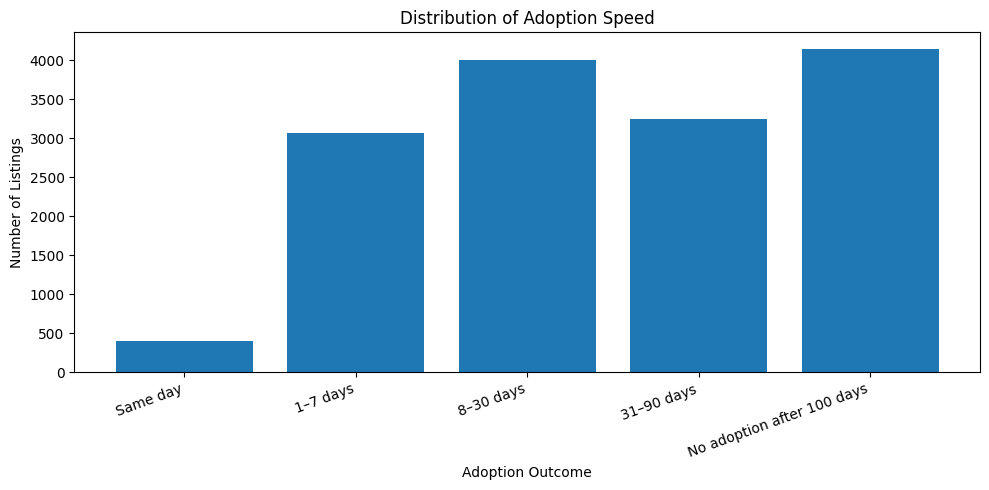

In [ ]:
labels = [
    'Same day',
    '1–7 days',
    '8–30 days',
    '31–90 days',
    'No adoption after 100 days'
]

plt.figure(figsize=(10, 5))
plt.bar(labels, adoption_counts.values)
plt.xlabel('Adoption Outcome')
plt.ylabel('Number of Listings')
plt.title('Distribution of Adoption Speed')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Description Length Analysis

 Description length is measured by the number of characters in each pet profile description.

In [ ]:
# Create a text-length feature based on the number of characters in the description.
train_text['desc_length'] = train_text['Description'].astype(str).apply(len)

train_text['desc_length'].describe()

,desc_length
count,14873.000000
mean,341.969408
std,373.686916
min,11.000000
25%,119.000000
50%,240.000000
75%,434.000000
max,6664.000000


In [ ]:
# Average description length by pet type.
avg_lengths = train_text.groupby('TypeLabel')['desc_length'].mean()
avg_lengths

,desc_length
TypeLabel,
Cat,354.430905
Dog,331.487126


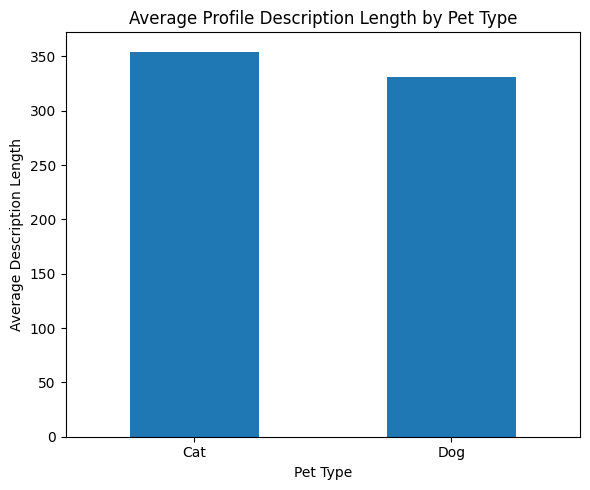

In [ ]:
plt.figure(figsize=(6, 5))
avg_lengths.plot(kind='bar')
plt.xlabel('Pet Type')
plt.ylabel('Average Description Length')
plt.title('Average Profile Description Length by Pet Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics for description length by adoption speed.
length_summary = train_text.groupby('AdoptionSpeed')['desc_length'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

length_summary

,count,mean,median,std,min,max
AdoptionSpeed,,,,,,
0,402,309.736318,229.5,298.950625,11,2150
1,3072,338.933594,249.0,344.653613,11,5798
2,4007,348.595708,243.0,377.804981,11,4545
3,3243,369.072772,257.0,414.683344,11,5955
4,4149,319.755845,220.0,361.399416,11,6664


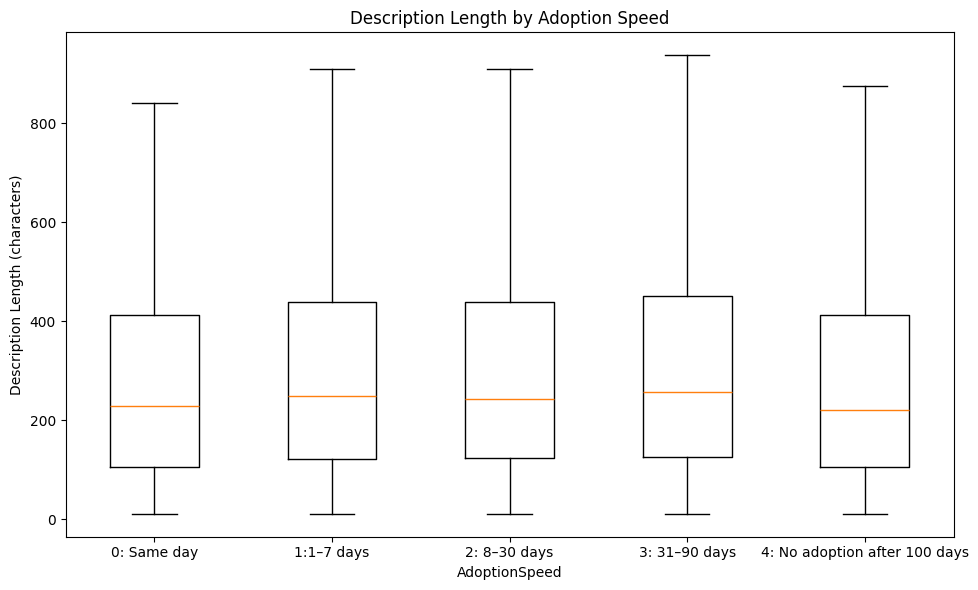

In [ ]:
# Create groups for the boxplot and ANOVA test.
length_groups = [
    train_text[train_text['AdoptionSpeed'] == i]['desc_length']
    for i in sorted(train_text['AdoptionSpeed'].unique())
]

boxplot_labels = [
    '0: Same day',
    '1:1–7 days',
    '2: 8–30 days',
    '3: 31–90 days',
    '4: No adoption after 100 days'
]

plt.figure(figsize=(10, 6))
plt.boxplot(length_groups, tick_labels=boxplot_labels, showfliers=False)
plt.xlabel('AdoptionSpeed')
plt.ylabel('Description Length (characters)')
plt.title('Description Length by Adoption Speed')
plt.tight_layout()
plt.savefig('boxplot_adoption_speed.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Statistical Tests for Description Length

Two statistical tests:

1. **One-way ANOVA** tests whether the average description length differs across the five adoption-speed groups.
2. **Spearman correlation** tests whether there is a monotonic relationship between description length and adoption speed.

Because the dataset is large, a statistically significant p-value does not automatically mean the effect is practically large. The size and direction of the relationship should also be interpreted.

In [ ]:
from scipy.stats import f_oneway, spearmanr

# ANOVA: compare description length across adoption speed groups.
f_stat, anova_p = f_oneway(*length_groups)

print('ANOVA F-statistic:', f_stat)
print('ANOVA p-value:', anova_p)

ANOVA F-statistic: 9.063268006877733
ANOVA p-value: 2.617950637815697e-07


In [ ]:
# Spearman correlation between description length and adoption speed.
corr, spearman_p = spearmanr(train_text['AdoptionSpeed'], train_text['desc_length'])

print('Spearman correlation:', corr)
print('Spearman p-value:', spearman_p)

Spearman correlation: -0.027582593188893376
Spearman p-value: 0.0007676868667763838


## 7. Create a Binary Adoption Outcome

The original `AdoptionSpeed` variable has five categories.

- `0`: Fast adoption, meaning same-day adoption or adoption within 1–7 days.
- `1`: Slower adoption, meaning adoption after 8 or more days, or no adoption after 100 days.



In [ ]:
train_text['AdoptionBinary'] = train_text['AdoptionSpeed'].apply(
    lambda x: 0 if x <= 1 else 1
)

train_text['AdoptionBinary'].value_counts()

,count
AdoptionBinary,
1,11399
0,3474


In [ ]:
# Check the proportion of each binary class.
train_text['AdoptionBinary'].value_counts(normalize=True)

,proportion
AdoptionBinary,
1,0.766422
0,0.233578


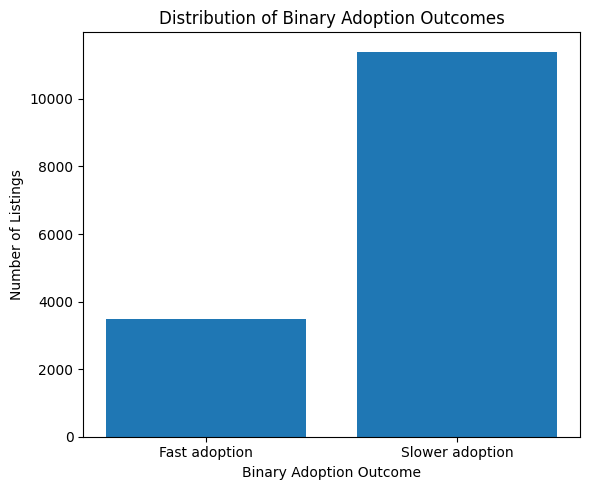

In [ ]:
binary_labels = ['Fast adoption', 'Slower adoption']
binary_counts = train_text['AdoptionBinary'].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(binary_labels, binary_counts.values)
plt.xlabel('Binary Adoption Outcome')
plt.ylabel('Number of Listings')
plt.title('Distribution of Binary Adoption Outcomes')
plt.tight_layout()
plt.show()

## 8. TF-IDF Text Classification Model

This section uses a TF-IDF representation of the profile descriptions and trains a Logistic Regression classifier.

Logistic Regression is used as a simple and interpretable baseline model for binary text classification.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

X = train_text['Description']
y = train_text['AdoptionBinary']

# Split the data into training and testing sets.
# stratify=y keeps the class proportions similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Convert text descriptions into TF-IDF features.
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Training TF-IDF shape:', X_train_tfidf.shape)
print('Testing TF-IDF shape:', X_test_tfidf.shape)

Training TF-IDF shape: (11898, 5000)
Testing TF-IDF shape: (2975, 5000)


In [ ]:
# Train the Logistic Regression model.
# class_weight='balanced' helps handle class imbalance
logreg_model = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_model.fit(X_train_tfidf, y_train)

# Predict adoption outcome on the test set.
y_pred_logreg = logreg_model.predict(X_test_tfidf)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_logreg))
print()
print(classification_report(y_test, y_pred_logreg, target_names=binary_labels))

Logistic Regression Accuracy: 0.6470588235294118

                 precision    recall  f1-score   support

  Fast adoption       0.34      0.53      0.41       695
Slower adoption       0.83      0.68      0.75      2280

       accuracy                           0.65      2975
      macro avg       0.58      0.61      0.58      2975
   weighted avg       0.71      0.65      0.67      2975



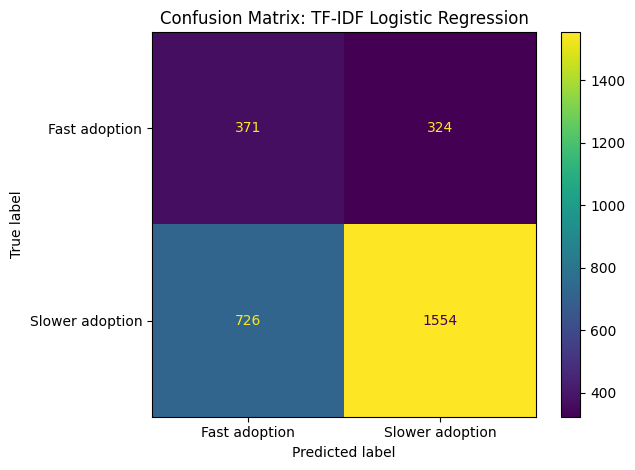

In [ ]:
# Confusion matrix for Logistic Regression.
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=binary_labels
)

disp.plot()
plt.title('Confusion Matrix: TF-IDF Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

The results highlight the impact of class imbalance on model performance. Without adjustment, the model tends to favor the majority class (slower adoption), resulting in high accuracy but poor detection of fast adoption cases.

After applying class weighting, the model achieves a more balanced performance, significantly improving recall for fast adoption. This demonstrates that accuracy alone is not a sufficient metric for evaluating models in imbalanced datasets.

## 9. Baseline Model



In [ ]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train_tfidf, y_train)

y_pred_baseline = baseline_model.predict(X_test_tfidf)

print('Baseline Accuracy:', accuracy_score(y_test, y_pred_baseline))
print()
print(classification_report(y_test, y_pred_baseline, target_names=binary_labels, zero_division=0))

Baseline Accuracy: 0.7663865546218488

                 precision    recall  f1-score   support

  Fast adoption       0.00      0.00      0.00       695
Slower adoption       0.77      1.00      0.87      2280

       accuracy                           0.77      2975
      macro avg       0.38      0.50      0.43      2975
   weighted avg       0.59      0.77      0.67      2975



## 10. Random Forest Comparison Model

To compare the Logistic Regression model with another approach, this section trains a Random Forest classifier. Logistic Regression is linear and often works well for sparse text features, while Random Forest is a non-linear ensemble method.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf, target_names=binary_labels))

Random Forest Accuracy: 0.7788235294117647

                 precision    recall  f1-score   support

  Fast adoption       0.65      0.11      0.19       695
Slower adoption       0.78      0.98      0.87      2280

       accuracy                           0.78      2975
      macro avg       0.72      0.55      0.53      2975
   weighted avg       0.75      0.78      0.71      2975



## 11. Model Comparison

This table compares the baseline, Logistic Regression, and Random Forest models. The key question is whether text features improve prediction beyond simply guessing the majority class.

In [ ]:
model_results = pd.DataFrame({
    'Model': ['Majority Baseline', 'TF-IDF + Logistic Regression', 'TF-IDF + Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf)
    ]
})

model_results

,Model,Accuracy
0,Majority Baseline,0.766387
1,TF-IDF + Logistic Regression,0.647059
2,TF-IDF + Random Forest,0.778824


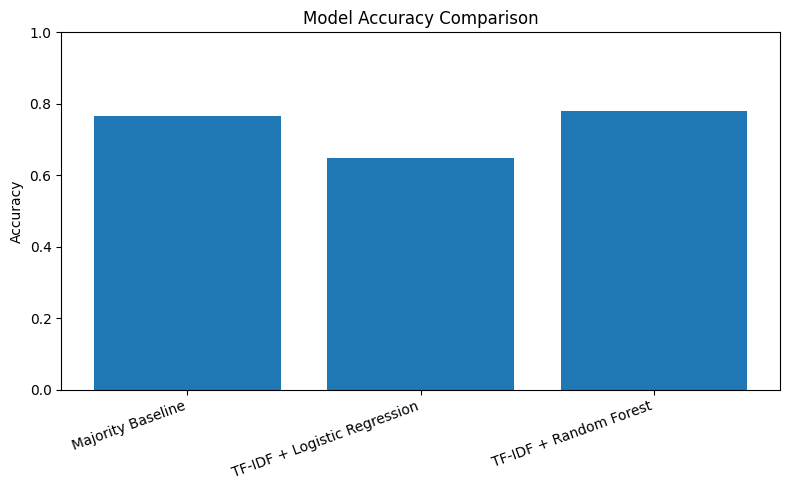

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(model_results['Model'], model_results['Accuracy'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

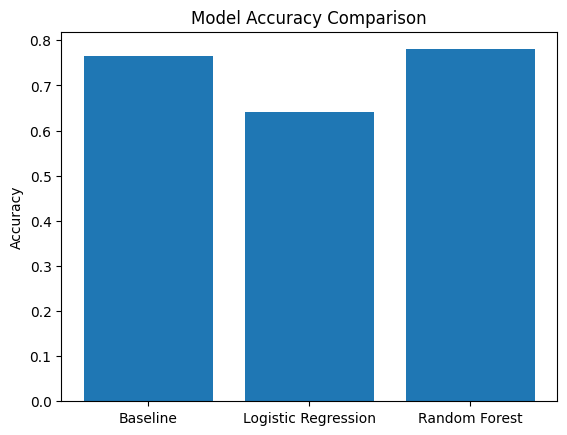

In [ ]:

models = ['Baseline', 'Logistic Regression', 'Random Forest']
accuracy = [0.766, 0.64, 0.78]

plt.bar(models, accuracy)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

These results suggest that text-based features provide only limited predictive power, as the models perform only slightly better than the baseline classifier.

## 12. Interpreting Important Words
Words with negative coefficients are more associated with the `Fast adoption` class, while words with positive coefficients are more associated with the `Slower adoption` class.

This does not prove that these words cause faster or slower adoption. Instead, it shows which words the model found useful for distinguishing the two outcome groups.

In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = logreg_model.coef_[0]

# Most negative coefficients are associated with fast adoption.
top_fast_idx = coefficients.argsort()[:20]

# Most positive coefficients are associated with slower adoption.
top_slow_idx = coefficients.argsort()[-20:]

top_fast_words = pd.DataFrame({
    'word': feature_names[top_fast_idx],
    'coefficient': coefficients[top_fast_idx]
})

top_slow_words = pd.DataFrame({
    'word': feature_names[top_slow_idx],
    'coefficient': coefficients[top_slow_idx]
})

print('Top words associated with fast adoption:')
display(top_fast_words)

print('Top words associated with slower adoption:')
display(top_slow_words)

Top words associated with fast adoption:


,word,coefficient
0,pick,-2.189236
1,fluffy,-2.050656
2,jin,-1.959950
3,poodle,-1.881908
4,19th,-1.858641
5,felicia,-1.834912
6,semi,-1.825868
7,profile,-1.810958
8,experience,-1.810860
9,coco,-1.714173


Top words associated with slower adoption:


,word,coefficient
0,family,1.382990
1,amy,1.383062
2,cost,1.394585
3,rachel,1.422395
4,borne,1.429417
5,seremban,1.433318
6,jocelyn,1.455453
7,close,1.477330
8,picked,1.508142
9,plz,1.519186


## 13. Sentiment Analysis

This section uses VADER sentiment analysis to calculate a compound sentiment score for each pet description. The compound score ranges from -1 to 1, where higher values indicate more positive sentiment.

This analysis tests whether more positive-sounding descriptions are associated with faster adoption outcomes.

In [ ]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

train_text['Sentiment_Compound'] = train_text['Description'].apply(
    lambda text: sia.polarity_scores(text)['compound']
)

train_text[['Description', 'Sentiment_Compound', 'AdoptionSpeed']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,Description,Sentiment_Compound,AdoptionSpeed
0,Nibble is a 3+ month old ball of cuteness. He ...,0.9552,2
1,I just found it alone yesterday near my apartm...,0.1280,0
2,Their pregnant mother was dumped by her irresp...,0.7650,3
3,"Good guard dog, very alert, active, obedience ...",0.9538,2
4,This handsome yet cute boy is up for adoption....,0.9880,2


In [ ]:
# Summary statistics for sentiment by adoption speed.
sentiment_summary = train_text.groupby('AdoptionSpeed')['Sentiment_Compound'].describe()
sentiment_summary

,count,mean,std,min,25%,50%,75%,max
AdoptionSpeed,,,,,,,,
0,402.0,0.662133,0.383259,-0.9246,0.461675,0.84305,0.955100,0.9969
1,3072.0,0.685146,0.391122,-0.9911,0.575200,0.86890,0.955025,0.9986
2,4007.0,0.711373,0.363535,-0.9816,0.612400,0.87790,0.956450,0.9989
3,3243.0,0.714857,0.372149,-0.9880,0.636000,0.88340,0.959800,0.9997
4,4149.0,0.681480,0.391811,-0.9750,0.541300,0.85760,0.954000,0.9991


<Figure size 800x500 with 0 Axes>

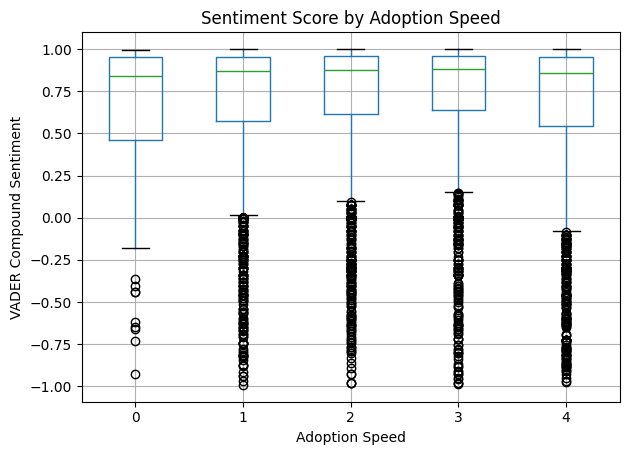

In [ ]:
plt.figure(figsize=(8, 5))
train_text.boxplot(column='Sentiment_Compound', by='AdoptionSpeed')
plt.title('Sentiment Score by Adoption Speed')
plt.suptitle('')
plt.xlabel('Adoption Speed')
plt.ylabel('VADER Compound Sentiment')
plt.tight_layout()
plt.show()

In [ ]:
# Spearman correlation between sentiment and adoption speed.
sentiment_corr = spearmanr(
    train_text['Sentiment_Compound'],
    train_text['AdoptionSpeed']
)

print('Spearman correlation:', sentiment_corr.correlation)
print('Spearman p-value:', sentiment_corr.pvalue)

Spearman correlation: -0.002987068372498765
Spearman p-value: 0.7156654728752481


## 14. Error Analysis

Error analysis helps explain where the model fails. The examples below show descriptions where the Logistic Regression model predicted the wrong binary adoption outcome.

These examples can be discussed in the paper to show that adoption is influenced by many factors beyond text, such as breed, age, photos, location, and health status.

In [ ]:
# Create a dataframe of test examples and predictions.
error_analysis = pd.DataFrame({
    'Description': X_test,
    'True_Label': y_test,
    'Predicted_Label': y_pred_logreg
})

# Keep only misclassified examples.
misclassified = error_analysis[error_analysis['True_Label'] != error_analysis['Predicted_Label']]

print('Number of misclassified examples:', misclassified.shape[0])
misclassified.head(10)

Number of misclassified examples: 1050


,Description,True_Label,Predicted_Label
3917,For Adoption,1,0
14641,Rescued from Kajang wet market from adult cat ...,1,0
5463,Cat for adoption,1,0
12096,For Adoption,1,0
14877,"rescued, lovable and active kitten looking for...",1,0
13117,"Fila Mastiff (Pure Breed)is a great guard dog,...",0,1
9535,playful and friendly kittens litter tray train...,1,0
11435,"RM including vaccineation,deworm, microchip an...",1,0
8528,An adorable active kitten. Super friendly.,1,0
11721,This dog was once owned by my neighbour when i...,0,1


## 15. Combine Text Features with Numeric Features

The model above only uses language from the description. However, adoption outcomes may also depend on non-text features such as age, number of photos, and adoption fee.

This optional section combines TF-IDF features with selected numeric features to test whether adding basic non-text information improves prediction.

In [ ]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

# Select simple numeric features that may influence adoption.
numeric_cols = ['Age', 'PhotoAmt', 'Fee']

X_numeric = train_text[numeric_cols].fillna(0)

# Split numeric features using the same train/test indices as the text split.
X_train_numeric = X_numeric.loc[X_train.index]
X_test_numeric = X_numeric.loc[X_test.index]

# Scale numeric features so they are on comparable ranges.
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

# Combine sparse TF-IDF features with numeric features.
X_train_combined = hstack([X_train_tfidf, X_train_numeric_scaled])
X_test_combined = hstack([X_test_tfidf, X_test_numeric_scaled])

print('Combined training shape:', X_train_combined.shape)
print('Combined testing shape:', X_test_combined.shape)

Combined training shape: (11898, 5003)
Combined testing shape: (2975, 5003)


In [ ]:
combined_model = LogisticRegression(max_iter=1000, class_weight='balanced')
combined_model.fit(X_train_combined, y_train)

y_pred_combined = combined_model.predict(X_test_combined)

print('Combined Model Accuracy:', accuracy_score(y_test, y_pred_combined))
print()
print(classification_report(y_test, y_pred_combined, target_names=binary_labels))

Combined Model Accuracy: 0.6443697478991597

                 precision    recall  f1-score   support

  Fast adoption       0.34      0.55      0.42       695
Slower adoption       0.83      0.67      0.74      2280

       accuracy                           0.64      2975
      macro avg       0.58      0.61      0.58      2975
   weighted avg       0.72      0.64      0.67      2975



In [ ]:
# Add the combined model to the comparison table.
model_results_extended = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'TF-IDF + Logistic Regression',
        'TF-IDF + Random Forest',
        'TF-IDF + Numeric Features'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_combined)
    ]
})

model_results_extended

,Model,Accuracy
0,Majority Baseline,0.766387
1,TF-IDF + Logistic Regression,0.647059
2,TF-IDF + Random Forest,0.778824
3,TF-IDF + Numeric Features,0.644370


## 16. Clustering Analysis of Description Types

In addition to supervised classification, I apply an unsupervised clustering method to explore whether there are distinct types of adoption descriptions.

Clustering helps identify common themes or styles in how pets are described, without using adoption outcome labels. This provides additional insight into how language patterns may relate to adoption success.

K-Means clustering on TF-IDF features to group descriptions into clusters based on similar language usage.

In [ ]:
from sklearn.cluster import KMeans

# Fit TF-IDF on full dataset (not just training split)
vectorizer_full = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000
)

X_tfidf_full = vectorizer_full.fit_transform(train_text['Description'])

# Apply K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
train_text['Cluster'] = kmeans.fit_predict(X_tfidf_full)

# Check cluster sizes
train_text['Cluster'].value_counts()

,count
Cluster,
3,9689
0,3462
1,875
4,501
2,346


In [ ]:
# Adoption distribution per cluster
pd.crosstab(
    train_text['Cluster'],
    train_text['AdoptionBinary'],
    normalize='index'
)

AdoptionBinary,0,1
Cluster,,
0,0.274697,0.725303
1,0.179429,0.820571
2,0.289017,0.710983
3,0.228610,0.771390
4,0.101796,0.898204


In [ ]:
import numpy as np

terms = vectorizer_full.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(5):
    print(f"\nCluster {i}:")
    print([terms[ind] for ind in order_centroids[i, :10]])


Cluster 0:
['cat', 'kitten', 'kittens', 'cats', 'playful', 'healthy', 'home', 'trained', 'active', 'litter']

Cluster 1:
['puppies', 'home', 'adoption', 'dog', 'female', 'mother', 'birth', 'cute', 'good', 'rescued']

Cluster 2:
['adoption', 'dog', 'cat', 'puppy', 'kittens', 'kitten', 'open', 'free', 'cute', 'contact']

Cluster 3:
['home', 'dog', 'good', 'puppy', 'loving', 'friendly', 'playful', 'adoption', 'active', 'owner']

Cluster 4:
['pls', 'contact', 'interested', 'puppy', 'adopt', 'home', 'commitment', 'looking', 'compulsory', 'rachel']


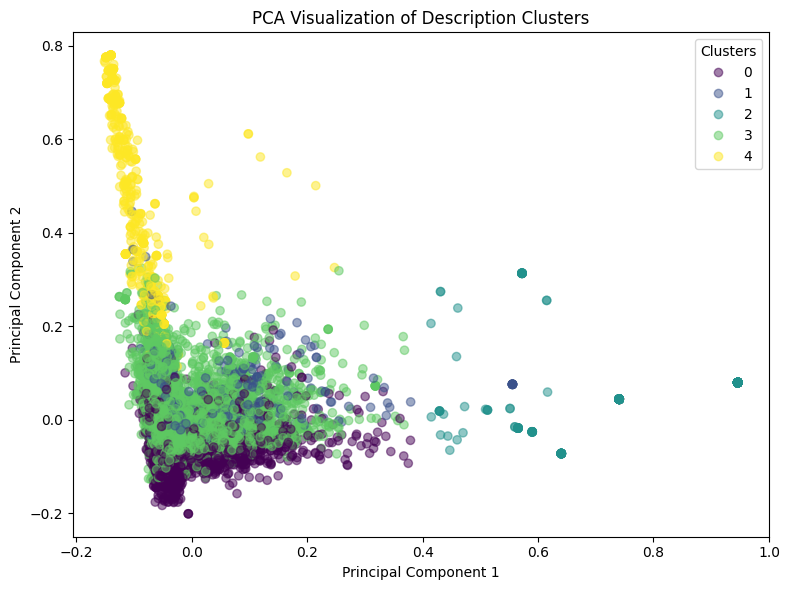

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X_tfidf_full.toarray())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=train_text['Cluster'],
    alpha=0.5
)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title('PCA Visualization of Description Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of Clustering Results

The clustering analysis reveals that adoption descriptions can be grouped into several distinct language patterns. Some clusters emphasize positive personality traits, while others include terms related to medical care, cost, or rescue situations.

The comparison of adoption outcomes across clusters shows that certain clusters are more associated with fast adoption. In particular, clusters containing more engaging and positive language tend to have a higher proportion of fast adoption cases. In contrast, clusters that include more references to health conditions or additional responsibilities are more associated with slower adoption.

However, the differences across clusters are moderate, and the PCA visualization shows that clusters overlap rather than forming clearly separated groups. This suggests that description styles exist along a continuum rather than as strictly distinct categories.

Overall, the clustering results support earlier findings that language patterns are related to adoption outcomes, but they are not sufficient to fully explain adoption behavior.

In [ ]:
cluster_adoption = pd.crosstab(
    train_text['Cluster'],
    train_text['AdoptionBinary'],
    normalize='index'
)

cluster_adoption.columns = ['Fast adoption', 'Slower adoption']

cluster_adoption

,Fast adoption,Slower adoption
Cluster,,
0,0.274697,0.725303
1,0.179429,0.820571
2,0.289017,0.710983
3,0.228610,0.771390
4,0.101796,0.898204


In [ ]:
# Cluster with highest fast adoption rate
best_cluster = cluster_adoption['Fast adoption'].idxmax()

# Cluster with lowest fast adoption rate
worst_cluster = cluster_adoption['Fast adoption'].idxmin()

best_cluster, worst_cluster

(np.int32(2), np.int32(4))

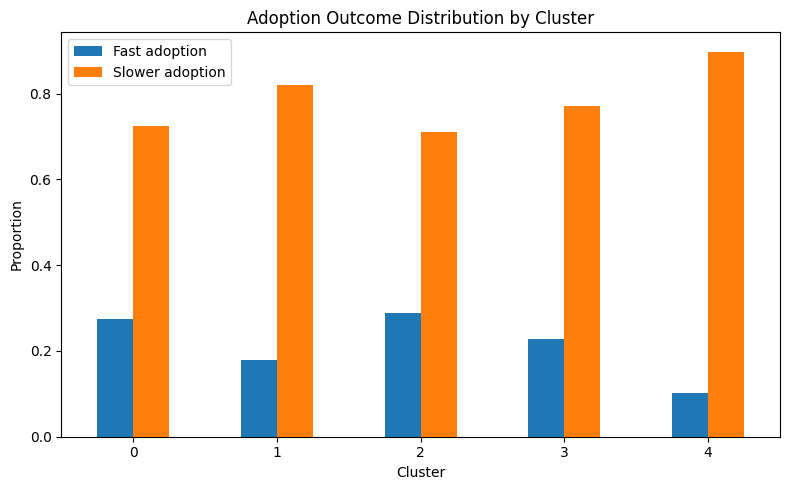

In [ ]:
cluster_adoption.plot(kind='bar', figsize=(8, 5))

plt.title('Adoption Outcome Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
for i in range(5):
    print(f"\nCluster {i}:")
    print([terms[ind] for ind in order_centroids[i, :10]])


Cluster 0:
['cat', 'kitten', 'kittens', 'cats', 'playful', 'healthy', 'home', 'trained', 'active', 'litter']

Cluster 1:
['puppies', 'home', 'adoption', 'dog', 'female', 'mother', 'birth', 'cute', 'good', 'rescued']

Cluster 2:
['adoption', 'dog', 'cat', 'puppy', 'kittens', 'kitten', 'open', 'free', 'cute', 'contact']

Cluster 3:
['home', 'dog', 'good', 'puppy', 'loving', 'friendly', 'playful', 'adoption', 'active', 'owner']

Cluster 4:
['pls', 'contact', 'interested', 'puppy', 'adopt', 'home', 'commitment', 'looking', 'compulsory', 'rachel']


In [ ]:
# Example descriptions from best cluster
train_text[train_text['Cluster'] == best_cluster]['Description'].sample(3)

,Description
9512,For Adoption
10340,Dog 4 Adoption
10781,For Adoption


In [ ]:
# Example descriptions from worst cluster
train_text[train_text['Cluster'] == worst_cluster]['Description'].sample(3)

,Description
13137,Healthy puppy looking for a home sweet home. N...
14039,I am intelligent and active. I am looking for ...
3754,I AM LOOKING A FOREVER HOME FOR HER....


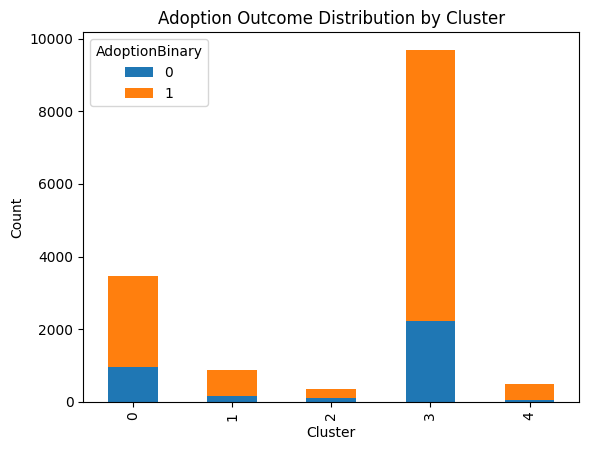

In [ ]:
pd.crosstab(
    train_text['Cluster'],
    train_text['AdoptionBinary']
).plot(kind='bar', stacked=True)

plt.title('Adoption Outcome Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

## 17. Linguistic Feature Analysis

While TF-IDF features and clustering capture general patterns in word usage, they do not directly reflect higher-level linguistic meaning. To better understand how language relates to adoption outcomes, I analyze emotional content in pet descriptions using a lexicon-based approach.

I apply the NRC Emotion Lexicon, which maps words to psychological emotion categories such as joy, sadness, fear, anger, and trust. This allows us to systematically measure the emotional tone of each description.

The goal of this analysis is to examine whether different emotional patterns are associated with adoption outcomes, providing a more interpretable view of how language may influence adoption.

In [ ]:
!pip uninstall -y nrclex NRCLex
!pip install NRCLex==3.0.0
!python -m textblob.download_corpora

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for NRCLex: filename=NRCLex-3.0.0-py3-none-any.whl size=43309 sha256=bf004b059330f361c71bdfe690d3791fc78c00ebb239b6696c0da2fe3e1efc99
  Stored in directory: /root/.cache/pip/wheels/1f/e8/d0/e3c3da0ef3b37ef4381dbf5c9401f3a9861a63ce221b13d8bb
Successfully built NRCLex
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movi

In [ ]:
from nrclex import NRCLex

test_text = "love"
emotion = NRCLex(test_text)

print(dir(emotion))
print(emotion.raw_emotion_scores)
print(emotion.affect_frequencies)

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'affect_dict', 'affect_frequencies', 'affect_list', 'append_text', 'lexicon', 'raw_emotion_scores', 'sentences', 'text', 'top_emotions', 'words']
{'joy': 1, 'positive': 1}
{'fear': 0.0, 'anger': 0.0, 'anticip': 0.0, 'trust': 0.0, 'surprise': 0.0, 'positive': 0.5, 'negative': 0.0, 'sadness': 0.0, 'disgust': 0.0, 'joy': 0.5}


In [ ]:
from nrclex import NRCLex
import pandas as pd
import matplotlib.pyplot as plt

emotion_cols = [
    'joy', 'sadness', 'fear', 'anger', 'trust',
    'positive', 'negative'
]

def get_emotion_scores(text):
    text = str(text)
    emotion = NRCLex(text)
    scores = emotion.affect_frequencies

    return pd.Series({
        col: scores.get(col, 0)
        for col in emotion_cols
    })

train_text[emotion_cols] = train_text['Description'].apply(get_emotion_scores)

emotion_summary = train_text.groupby('AdoptionBinary')[emotion_cols].mean()
emotion_summary_readable = emotion_summary.copy()
emotion_summary_readable.index = ['Fast adoption', 'Slower adoption']

emotion_summary_readable

,joy,sadness,fear,anger,trust,positive,negative
Fast adoption,0.138927,0.047223,0.026992,0.026805,0.145522,0.274204,0.075547
Slower adoption,0.137179,0.047014,0.029860,0.027665,0.146337,0.282019,0.077707


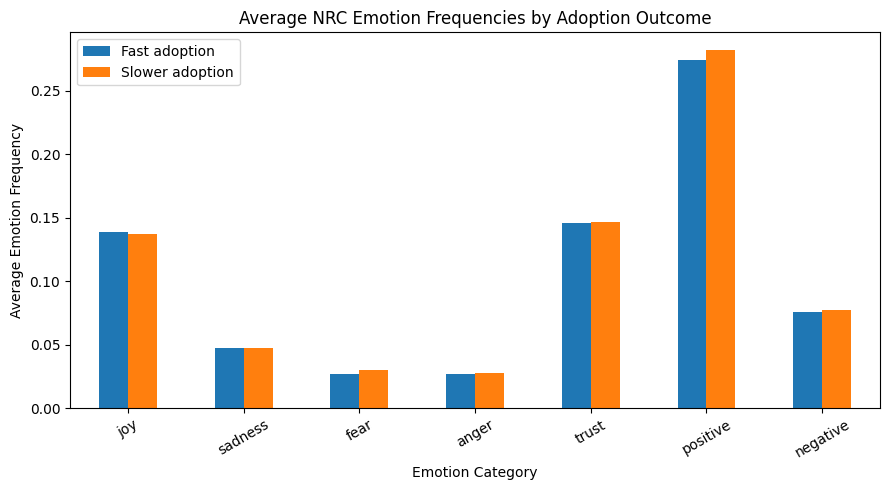

In [ ]:
emotion_summary_readable.T.plot(kind='bar', figsize=(9, 5))

plt.title('Average NRC Emotion Frequencies by Adoption Outcome')
plt.xlabel('Emotion Category')
plt.ylabel('Average Emotion Frequency')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('nrc_emotion_scores.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of Linguistic Features

The NRC Emotion Lexicon analysis shows only small differences between fast and slower adoption descriptions. Both groups exhibit similar levels of joy, trust, and other emotional categories.

Fast adoption descriptions show slightly higher levels of positive emotions such as joy, while slower adoption descriptions show slightly higher levels of fear and negative emotion. However, these differences are minimal, indicating that broad emotional tone alone is not a strong distinguishing factor.

This suggests that more specific linguistic features, such as references to health conditions, cost, or personality traits, may be more informative than general emotional tone. These findings are consistent with earlier results from the classification and clustering analyses, reinforcing the conclusion that language provides some signal but is not sufficient to fully explain adoption outcomes.

## 18. Topic Analysis by Adoption Outcome

To further understand how language differs between adoption outcomes, I analyze the most prominent words associated with fast and slower adoption descriptions.

Instead of clustering all descriptions together, I separate the dataset by adoption outcome and extract the most important terms within each group. This allows us to identify common themes that characterize fast and slower adoption cases.

In [ ]:
fast_texts = train_text[train_text['AdoptionBinary'] == 0]['Description']
slow_texts = train_text[train_text['AdoptionBinary'] == 1]['Description']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_fast = TfidfVectorizer(stop_words='english', max_features=1000)
vectorizer_slow = TfidfVectorizer(stop_words='english', max_features=1000)

X_fast = vectorizer_fast.fit_transform(fast_texts)
X_slow = vectorizer_slow.fit_transform(slow_texts)

In [ ]:
import numpy as np

def get_top_words(vectorizer, X, n=20):
    words = np.array(vectorizer.get_feature_names_out())
    scores = np.asarray(X.mean(axis=0)).ravel()
    top_idx = scores.argsort()[-n:][::-1]
    return words[top_idx]

top_fast_words = get_top_words(vectorizer_fast, X_fast)
top_slow_words = get_top_words(vectorizer_slow, X_slow)

print("Top words in FAST adoption:")
print(top_fast_words)

print("\nTop words in SLOW adoption:")
print(top_slow_words)

Top words in FAST adoption:
['adoption' 'home' 'cat' 'dog' 'kitten' 'playful' 'adopt' 'puppy' 'active'
 'good' 'cute' 'looking' 'healthy' 'interested' 'contact' 'old' 'loving'
 'kittens' 'owner' 'love']

Top words in SLOW adoption:
['home' 'adoption' 'dog' 'cat' 'good' 'contact' 'adopt' 'playful'
 'looking' 'puppy' 'interested' 'loving' 'active' 'cute' 'healthy'
 'friendly' 'kitten' 'old' 'puppies' 'love']


### Interpretation of Themes

The topic analysis shows that fast and slower adoption descriptions share very similar vocabulary and themes. Both groups frequently include words related to general pet descriptions, such as “home,” “dog,” “cat,” “playful,” and “loving.”

This suggests that the overall themes of adoption descriptions are largely consistent across outcomes. Most descriptions emphasize basic information about the pet and its suitability for adoption, regardless of whether the pet is adopted quickly or slowly.

The lack of clear thematic differences indicates that general descriptive language alone is not sufficient to distinguish adoption outcomes. Instead, more subtle linguistic patterns—such as how information is framed, references to health or cost, or non-textual factors like photos and breed—may play a more important role.

These findings are consistent with earlier results from the classification and clustering analyses, which also showed that text provides only limited predictive power.

In [ ]:
special_needs_words = [
    'injured', 'sick', 'treatment', 'medication', 'vet',
    'condition', 'recovery', 'special', 'care', 'needs',
    'disabled', 'blind', 'disease'
]

In [ ]:
def has_special_needs(text):
    words = str(text).lower().split()
    return any(word in words for word in special_needs_words)

train_text['SpecialNeeds'] = train_text['Description'].apply(has_special_needs)

In [ ]:
pd.crosstab(
    train_text['SpecialNeeds'],
    train_text['AdoptionBinary'],
    normalize='index'
)

AdoptionBinary,0,1
SpecialNeeds,,
False,0.236553,0.763447
True,0.223820,0.776180


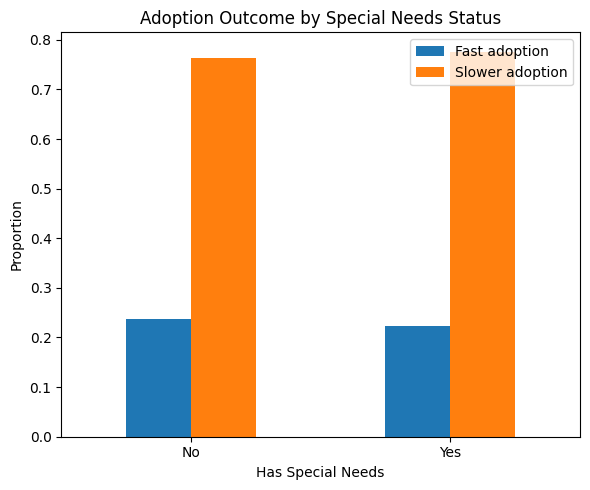

In [ ]:
special_adoption = pd.crosstab(
    train_text['SpecialNeeds'],
    train_text['AdoptionBinary'],
    normalize='index'
)

special_adoption.columns = ['Fast adoption', 'Slower adoption']

special_adoption.plot(kind='bar', figsize=(6, 5))

plt.title('Adoption Outcome by Special Needs Status')
plt.xlabel('Has Special Needs')
plt.ylabel('Proportion')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

## Overall Findings

Across multiple methods, the results consistently show that language provides only limited predictive power for adoption outcomes.

The classification models achieved performance only slightly above baseline, and clustering revealed overlapping description styles rather than clearly distinct groups. Similarly, topic analysis showed that fast and slower adoption descriptions share very similar vocabulary, and emotion analysis indicated only minimal differences in emotional tone.

Even targeted analysis of specific factors, such as special needs, showed only weak and statistically non-significant effects.

Taken together, these findings suggest that while language reflects certain aspects of how pets are presented, it is not a dominant factor in determining adoption speed. Instead, adoption outcomes are likely influenced by a combination of non-textual factors such as visual appearance, breed, age, and adopter preferences.

In [ ]:
# Filter out very short or non-informative descriptions
meaningful_text = train_text[
    (train_text['desc_length'] > 10) &
    (train_text['Description'].str.contains(r'[A-Za-z]', regex=True)) &
    (~train_text['Description'].str.lower().str.strip().isin(['nil', 'na', 'n/a', 'none']))
].copy()

# Sort by shortest meaningful descriptions
five_shortest_meaningful = meaningful_text.sort_values('desc_length').head(5)

for i, row in five_shortest_meaningful.iterrows():
    print("=" * 80)
    print("Description length:", row['desc_length'])
    print("AdoptionSpeed:", row['AdoptionSpeed'])
    print("Type:", row['TypeLabel'])
    print("Description:")
    print(row['Description'])

Description length: 11
AdoptionSpeed: 0
Type: Cat
Description:
like to eat
Description length: 11
AdoptionSpeed: 1
Type: Cat
Description:
Cute kitten
Description length: 11
AdoptionSpeed: 2
Type: Dog
Description:
Rescued pup
Description length: 11
AdoptionSpeed: 1
Type: Cat
Description:
very active
Description length: 11
AdoptionSpeed: 3
Type: Cat
Description:
Very active


In [ ]:
# Print the longest description in the cleaned dataset
longest_idx = train_text['desc_length'].idxmax()

print("Longest description length:", train_text.loc[longest_idx, 'desc_length'])
print("AdoptionSpeed:", train_text.loc[longest_idx, 'AdoptionSpeed'])
print("Type:", train_text.loc[longest_idx, 'TypeLabel'])
print("\nDescription:")
print(train_text.loc[longest_idx, 'Description'])

Longest description length: 6664
AdoptionSpeed: 4
Type: Dog

Description:
Gabby is a beautiful sleek black puppy, estimated to be at 3 months old when she turned up. That was in March . Gabby is a lovely quiet dog that hardly barks. She loves to sit and watch us when we are gardening, or sit with us when we are at ease at the porch area. Our friends who visited us, remarked what a gentle soul Gabby is. The children had no problems playing with her as Gabby is not rough. We have recently had a BBQ party & we've received encouraging remarks that Gabby does not paw, bite or disturb any of the guests when they eat or drink. Gabby was lured to our neighborhood by an irresponsible family who was unable to care for her. We gave our home as Gabby's shelter, in order for Gabby to be safe from traffic, pedestrian abuse and harsh outdoor weather. This beautiful puppy is growing up in our compound and is turning out to be a gentle dog who loves long walks, tummy rubs, sitting with us during evenin